# 01 — EDA maestro (datos v2)

> Análisis exploratorio **causal** de las 166 series descargadas, condensado. Recomputa en vivo
> los hallazgos-cabecera de la Fase 3. El informe completo (7 temas, todas las cifras y figuras) está
> en **`docs/EDA_v2.md`**; el banco congelado en **`data/benchmark_spec.yaml`**.

**Dos pistas** (ADR-001): **A** = espina profunda (SP500+vol, 1927+, 22 crisis → potencia);
**B** = panel rico (crédito/curva/vol/FX, 2003+, 10 crisis → riqueza, ataca 2013).
**Regla de oro**: toda feature es causal (z-score expanding, estadísticos ≤ t).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT/'data'/'catalog.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import features as ft
import yaml
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':.3,'font.size':9})

cov = pd.read_csv(ROOT/'data'/'raw'/'coverage_report.csv')
SRC = dict(zip(cov.nombre, cov.fuente))
def load(name):
    return pd.read_parquet(ROOT/'data'/'raw'/SRC[name]/f'{name}.parquet')[name].sort_index()
cat = yaml.safe_load((ROOT/'data'/'catalog.yaml').read_text(encoding='utf-8'))
bench = yaml.safe_load((ROOT/'data'/'benchmark_spec.yaml').read_text(encoding='utf-8'))
EV = pd.DataFrame(cat['crisis_catalog']['eventos'])
EV['peak']=pd.to_datetime(EV['peak']); EV['trough']=pd.to_datetime(EV['trough'])
def crisis_mask(idx):
    m = pd.Series(False, index=idx)
    for _,r in EV.iterrows(): m |= (idx>=r['peak'])&(idx<=r['trough'])
    return m
print('series disponibles:', (cov.status.isin(['OK','CACHE'])).sum(), '| crisis catalogadas:', len(EV))

series disponibles: 166 | crisis catalogadas: 22


## 1. Los números que hay que retener

In [2]:
spx = load('SP500'); r = np.log(spx/spx.shift(1)).dropna()
print(f"SP500 diario {spx.index.min().date()}..{spx.index.max().date()}  (n={len(r)})")
print(f"  curtosis exceso = {stats.kurtosis(r):.1f}  |  skew = {stats.skew(r):.2f}")
print(f"  Jarque-Bera p = {stats.jarque_bera(r)[1]:.0e}  -> normalidad RECHAZADA")
print(f"  dias |r|>5sigma = {(r.abs()>5*r.std()).sum()}  (esperados bajo Normal ~ {len(r)*2*stats.norm.sf(5):.2f})")
for y in [1927,1962,1990,2003]:
    n=(EV.peak.dt.year>=y).sum(); print(f"  crisis con pico >= {y}: {n}/{len(EV)}")

SP500 diario 1927-12-30..2026-07-17  (n=24751)


  curtosis exceso = 18.7  |  skew = -0.47
  Jarque-Bera p = 0e+00  -> normalidad RECHAZADA
  dias |r|>5sigma = 108  (esperados bajo Normal ~ 0.01)
  crisis con pico >= 1927: 22/22
  crisis con pico >= 1962: 18/22
  crisis con pico >= 1990: 13/22
  crisis con pico >= 2003: 10/22


## 2. Fat tails: el gaussiano está mal especificado (motiva t-Student)

       serie        clase     n  kurt_exc  skew
       SP500       equity 24751      18.7 -0.47
  HYG_CREDIT   credito HY  4847      39.7  0.31
TLT_TREASURY treasury 20y  6029       3.4 -0.02
    GOLD_GLD          oro  5447       6.7 -0.46
         DXY        dolar 14101       3.7 -0.08


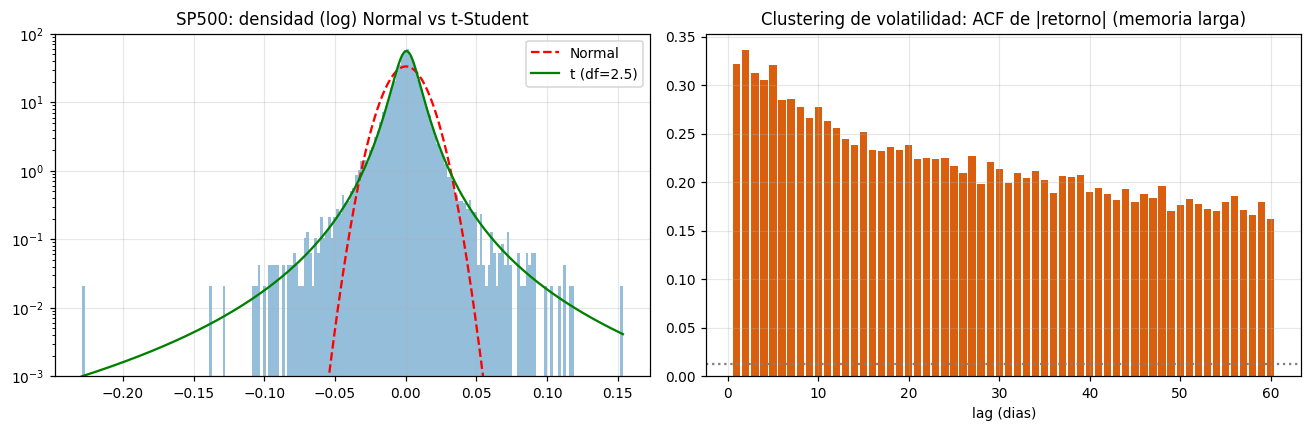

In [3]:
assets = [('SP500','equity'),('HYG_CREDIT','credito HY'),('TLT_TREASURY','treasury 20y'),
          ('GOLD_GLD','oro'),('DXY','dolar')]
rows=[]
for n,lab in assets:
    try:
        s=load(n); rr=np.log(s/s.shift(1)).dropna()
        rows.append({'serie':n,'clase':lab,'n':len(rr),'kurt_exc':round(stats.kurtosis(rr),1),'skew':round(stats.skew(rr),2)})
    except Exception as e: pass
tab=pd.DataFrame(rows); print(tab.to_string(index=False))

fig,ax=plt.subplots(1,2,figsize=(12,4))
x=np.linspace(r.min(),r.max(),400)
ax[0].hist(r,bins=200,density=True,alpha=.5,color='#2c7fb8')
ax[0].plot(x,stats.norm.pdf(x,r.mean(),r.std()),'r--',label='Normal')
df,loc,sc=stats.t.fit(r); ax[0].plot(x,stats.t.pdf(x,df,loc,sc),'g-',label=f't (df={df:.1f})')
ax[0].set_yscale('log'); ax[0].set_ylim(1e-3,1e2); ax[0].legend(); ax[0].set_title('SP500: densidad (log) Normal vs t-Student')
lag=np.arange(1,61); acf=[r.abs().autocorr(l) for l in lag]
ax[1].bar(lag,acf,color='#d95f0e'); ax[1].axhline(2/np.sqrt(len(r)),ls=':',c='grey')
ax[1].set_title('Clustering de volatilidad: ACF de |retorno| (memoria larga)'); ax[1].set_xlabel('lag (dias)')
plt.tight_layout(); plt.show()

## 3. La correlación acción–bono cambia de signo (~2000) → tipifica el régimen

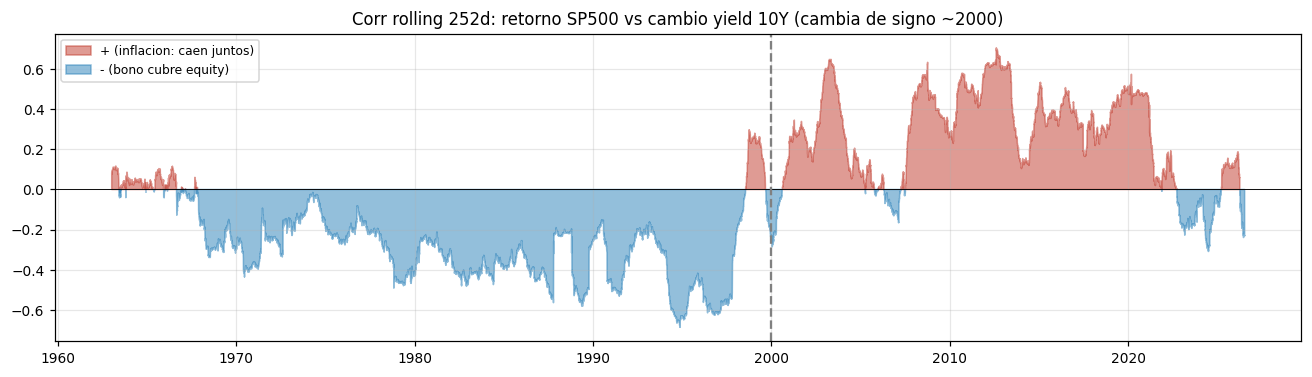

In [4]:
dgs=load('DGS10'); dy=dgs.diff()  # cambio de yield (proxy retorno bono, historia larga)
common=r.index.intersection(dy.index)
roll=r.reindex(common).rolling(252).corr(dy.reindex(common)).dropna()
fig,ax=plt.subplots(figsize=(12,3.5))
ax.fill_between(roll.index,0,roll.values,where=roll>0,color='#c0392b',alpha=.5,label='+ (inflacion: caen juntos)')
ax.fill_between(roll.index,0,roll.values,where=roll<=0,color='#2980b9',alpha=.5,label='- (bono cubre equity)')
ax.axhline(0,c='k',lw=.6); ax.axvline(pd.Timestamp('2000-01-01'),ls='--',c='grey')
ax.set_title('Corr rolling 252d: retorno SP500 vs cambio yield 10Y (cambia de signo ~2000)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Crédito/curva y el punto ciego 2013: shock de TIPOS puro (no crisis) → solo la VELOCIDAD lo ve

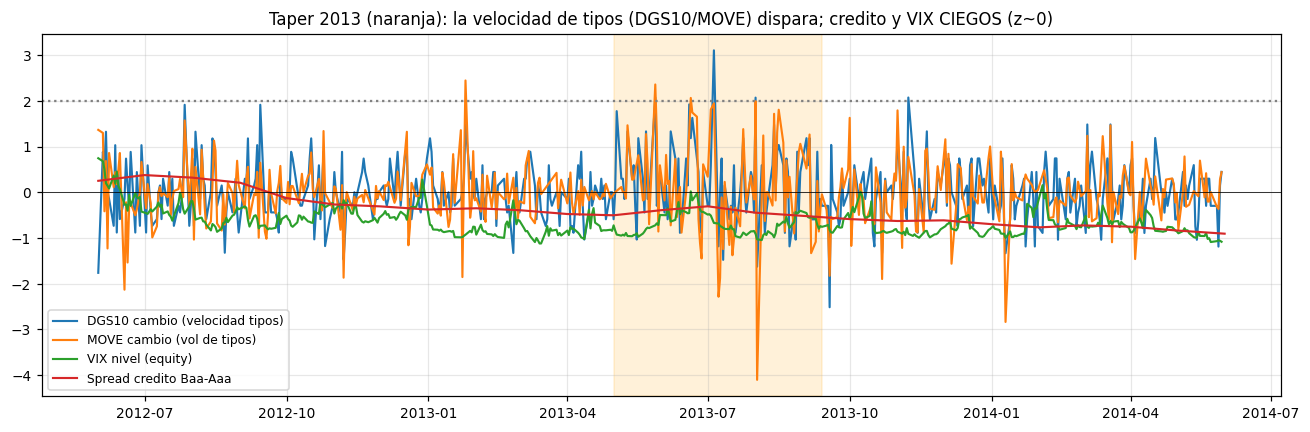

Pico z en 2013 (mayo-sep):
  DGS10 cambio (velocidad tipos)   z_max = 3.11
  MOVE cambio (vol de tipos)       z_max = 2.36
  VIX nivel (equity)               z_max = 0.02
  Spread credito Baa-Aaa           z_max = -0.31


In [5]:
def cz(s): return ft.causal_zscore(s.rename(s.name or 'x'))
win=slice('2012-06-01','2014-06-01')
dgs10=load('DGS10'); move=load('MOVE'); vix=load('VIX')
baa=load('MOODYS_BAA'); aaa=load('MOODYS_AAA'); credit=(baa-aaa).rename('credit')
z = {
 'DGS10 cambio (velocidad tipos)': cz(dgs10.diff().rename('d10')),
 'MOVE cambio (vol de tipos)': cz(move.diff().rename('dmove')),
 'VIX nivel (equity)': cz(vix.rename('vix')),
 'Spread credito Baa-Aaa': cz(credit),
}
fig,ax=plt.subplots(figsize=(12,4))
for lab,zz in z.items():
    seg=zz.loc[win].dropna(); ax.plot(seg.index,seg.values,label=lab,lw=1.4)
ax.axvspan(pd.Timestamp('2013-05-01'),pd.Timestamp('2013-09-13'),color='orange',alpha=.15)
ax.axhline(0,c='k',lw=.5); ax.axhline(2,ls=':',c='grey')
ax.set_title('Taper 2013 (naranja): la velocidad de tipos (DGS10/MOVE) dispara; credito y VIX CIEGOS (z~0)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print('Pico z en 2013 (mayo-sep):')
for lab,zz in z.items(): print(f'  {lab:32} z_max = {zz.loc["2013-05-01":"2013-09-30"].max():.2f}')

## 5. Profundidad = potencia: la espina 1927 ve 22 crisis (2.2× el panel de 2007)

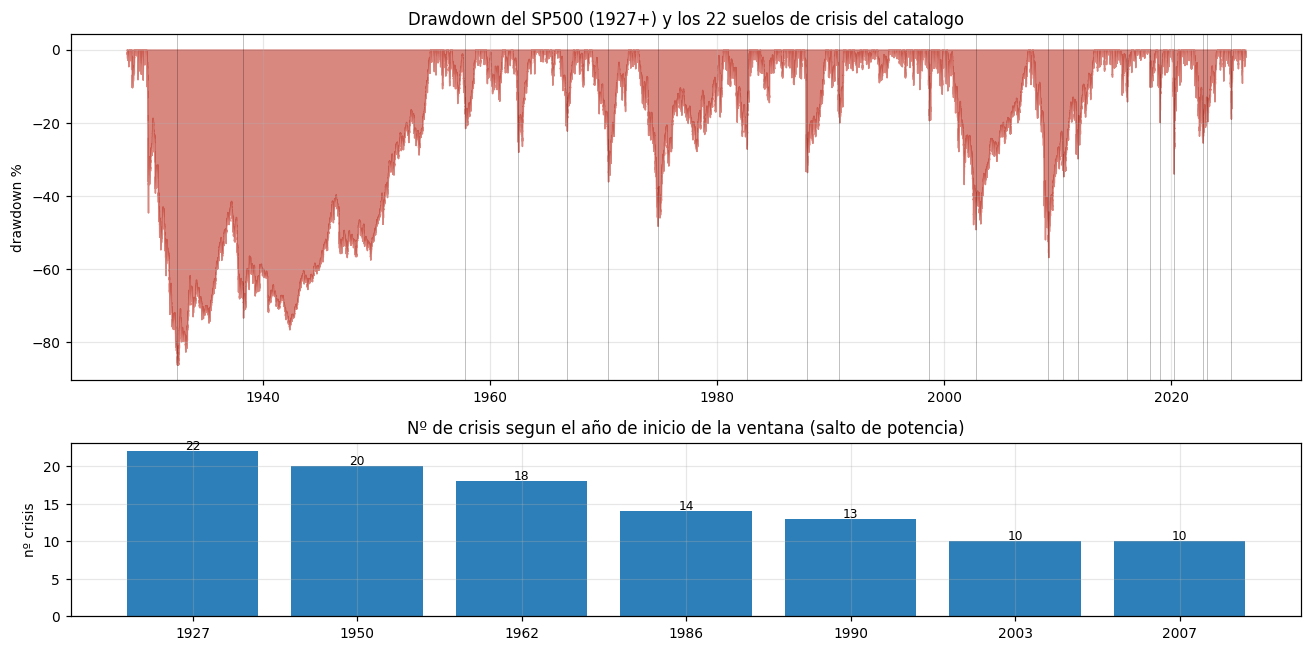

In [6]:
dd=(spx/spx.cummax()-1)
fig,ax=plt.subplots(2,1,figsize=(12,6),height_ratios=[2,1])
ax[0].fill_between(dd.index,dd.values*100,0,color='#c0392b',alpha=.6); ax[0].set_ylabel('drawdown %')
for _,e in EV.iterrows(): ax[0].axvline(e['trough'],c='k',lw=.4,alpha=.4)
ax[0].set_title(f'Drawdown del SP500 (1927+) y los {len(EV)} suelos de crisis del catalogo')
yrs=[1927,1950,1962,1986,1990,2003,2007]; ncr=[(EV.peak.dt.year>=y).sum() for y in yrs]
ax[1].bar([str(y) for y in yrs],ncr,color='#2c7fb8')
for i,v in enumerate(ncr): ax[1].text(i,v+.2,v,ha='center',fontsize=8)
ax[1].set_title('Nº de crisis segun el año de inicio de la ventana (salto de potencia)'); ax[1].set_ylabel('nº crisis')
plt.tight_layout(); plt.show()

## 6. Poder discriminante causal de las features (crisis vs calma)

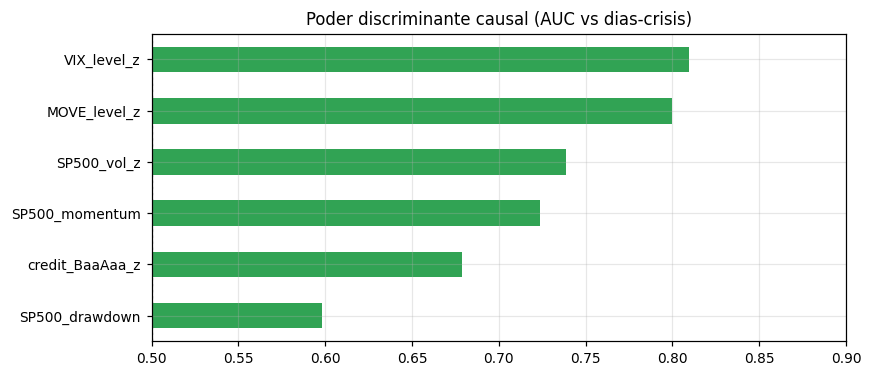

VIX_level_z        0.810
MOVE_level_z       0.800
SP500_vol_z        0.739
SP500_momentum     0.724
credit_BaaAaa_z    0.679
SP500_drawdown     0.598


In [7]:
def auc_vs_crisis(z):
    z=z.dropna(); m=crisis_mask(z.index)
    a,b=z[m], z[~m]
    if len(a)<30 or len(b)<30: return np.nan
    # AUC = P(feature en crisis > feature en calma) via Mann-Whitney
    U=stats.mannwhitneyu(a,b,alternative='two-sided').statistic
    auc=U/(len(a)*len(b)); return max(auc,1-auc)
feats={
 'VIX_level_z': cz(load('VIX').rename('vix')),
 'MOVE_level_z': cz(load('MOVE').rename('move')),
 'credit_BaaAaa_z': cz((load('MOODYS_BAA')-load('MOODYS_AAA')).rename('cr')),
 'SP500_vol_z': cz(ft.realized_vol(r).rename('vol')),
 'SP500_momentum': ft.momentum(spx),
 'SP500_drawdown': ft.drawdown(spx),
}
rk=pd.Series({k:auc_vs_crisis(v) for k,v in feats.items()}).sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(8,3.5)); rk.plot.barh(ax=ax,color='#31a354'); ax.invert_yaxis()
ax.axvline(.5,ls=':',c='grey'); ax.set_xlim(.5,.9); ax.set_title('Poder discriminante causal (AUC vs dias-crisis)')
plt.tight_layout(); plt.show(); print(rk.round(3).to_string())

## 7. El banco congelado (variable controlada de la Fase D)

In [8]:
for p in ['pista_A','pista_B']:
    b=bench[p]; print(f"{p}: {b['ventana_inicio']} -> {b['ventana_fin']} | {b['n_crisis_en_ventana']} crisis | {len(b['series_features'])} series-feature ({b['objetivo']})")
print('\ncrisis_windows pista_A:', len(bench['crisis_windows']['pista_A']), '| pista_B:', len(bench['crisis_windows']['pista_B']))
print('false_positive_windows:', list(bench['false_positive_windows'].keys()))

pista_A: 1927-12-30 -> 2026-05-29 | 22 crisis | 8 series-feature (potencia)
pista_B: 2003-01-02 -> 2026-07-10 | 10 crisis | 24 series-feature (riqueza)

crisis_windows pista_A: 22 | pista_B: 10
false_positive_windows: ['taper_2013', 'debtceiling_2013', 'selloff_2018', 'otras_trampas_no_caracterizadas']


## Conclusiones

1. **Colas gordas universales** (SP500 curtosis ≫ 0, JB rechaza normal) → el detector debe usar **t-Student**, no gaussiano.
2. **Clustering de volatilidad** (ACF de |r| con memoria) → la vol es el sensor de régimen más robusto.
3. **La correlación acción–bono cambia de signo ~2000** → el régimen no es solo "vol alta/baja"; hay un eje inflación↔crecimiento.
4. **2013 no es una crisis, es una trampa de tipos**: solo la **velocidad de tipos** (DGS10/MOVE change) la ve; crédito/VIX ciegos, y es correcto que no disparen.
5. **Profundidad = potencia**: la espina de 1927 da 22 crisis (Pista A); el panel rico de 2003 da 10 pero discrimina mejor (Pista B). Por eso **dos pistas**.

→ Detalle completo en `docs/EDA_v2.md`; banco congelado en `data/benchmark_spec.yaml`.